In [1]:
%matplotlib ipympl

In [7]:
# https://www.ercot.com/files/docs/2009/05/20/modelingguidelines_v06.pdf

In [26]:
import pandas as pd
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient
from datetime import date
import numpy as np
from scipy.stats.mstats import winsorize
import statsmodels.formula.api as smf
from noaa.noaa_snowflake import get_noaa_weather_data
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [3]:
client = ModoEnergyAPIClient(cache_requests=True)

In [4]:
start = date(2024, 7, 1)
end = date(2026, 5, 31)

In [5]:
prices = client.get_ercot_prices(date_from=start, date_to=end)

Fetching pages : 0page [00:00, ?page/s]

In [6]:
hb_bus_avg_price = prices[prices["settlementPointName"] == "HB_HOUSTON"][
    "settlementPointPrice"
].astype(int)

In [7]:
hb_bus_avg_price_winsorized = pd.DataFrame(
    {hb_bus_avg_price.name: winsorize(hb_bus_avg_price, limits=[None, 0.01])},
    index=hb_bus_avg_price.index,
)

In [8]:
arbitrage_opportunity = (
    hb_bus_avg_price_winsorized.resample("D")
    .agg(lambda d: d[d.index.hour == 19].item() - d[d.index.hour == 12].item())
    .rename(columns={"settlementPointPrice": "arbitrage_opportunity"})
).astype(int)


In [9]:
weather_data = get_noaa_weather_data()

In [27]:
min_max_scaler = preprocessing.MinMaxScaler()

In [34]:
time_span_weather_data = weather_data[weather_data.index > pd.to_datetime(start)]
wind_speed = time_span_weather_data[["Average daily wind speed"]]
wind_speed_normalized = pd.DataFrame(
    min_max_scaler.fit_transform(wind_speed),
    columns=wind_speed.columns,
    index=wind_speed.index,
)

In [35]:
arbitrage_opportunity_normalized = pd.DataFrame(
    min_max_scaler.fit_transform(arbitrage_opportunity),
    columns=arbitrage_opportunity.columns,
    index=arbitrage_opportunity.index,
)

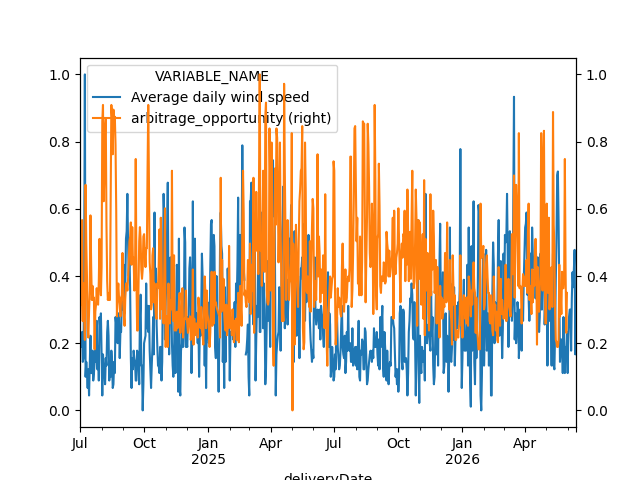

In [37]:
plt.clf()
wind_speed_plot = wind_speed_normalized.plot(
    legend=True, label="Average daily wind speed"
)
arbitrage_opportunity_normalized.plot(ax=wind_speed_plot, secondary_y=True)
plt.show()

In [32]:
wind_speed_normalized

array([[0.2       ],
       [0.18888889],
       [0.23333333],
       [0.14444444],
       [0.15555556],
       [0.42222222],
       [1.        ],
       [0.1       ],
       [0.14444444],
       [0.11111111],
       [0.06666667],
       [0.12222222],
       [0.04444444],
       [0.13333333],
       [0.22222222],
       [0.11111111],
       [0.11111111],
       [0.17777778],
       [0.08888889],
       [0.11111111],
       [0.14444444],
       [0.21111111],
       [0.14444444],
       [0.26666667],
       [0.12222222],
       [0.18888889],
       [0.08888889],
       [0.27777778],
       [0.24444444],
       [0.28888889],
       [0.16666667],
       [0.04444444],
       [0.16666667],
       [0.13333333],
       [0.11111111],
       [0.07777778],
       [0.15555556],
       [0.13333333],
       [0.23333333],
       [0.26666667],
       [0.22222222],
       [0.08888889],
       [0.12222222],
       [0.1       ],
       [0.17777778],
       [0.14444444],
       [0.06666667],
       [0.077

In [24]:
# wind speed and arbitrage are coorelated

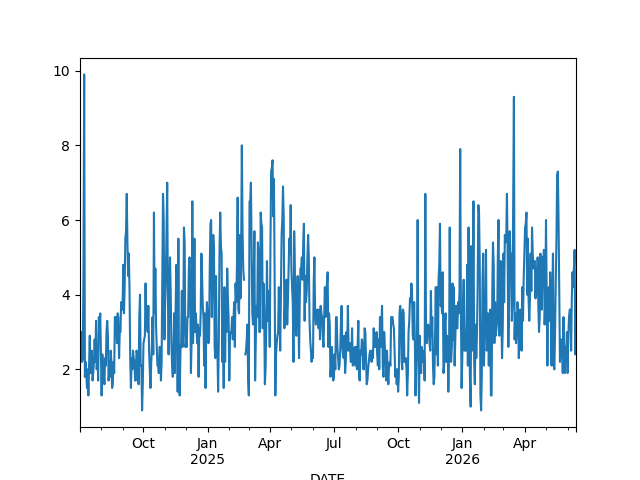

In [20]:
plt.clf()
wind_speed.plot()
plt.show()

In [34]:
X = pd.DataFrame(
    {
        "month": arbitrage_opportunity.index.month,
        "day_of_week": arbitrage_opportunity.index.day_of_week,
        "arbitrage_opportunity": arbitrage_opportunity["arbitrage_opportunity"],
    },
    index=arbitrage_opportunity.index,
)

In [40]:
model = smf.ols("arbitrage_opportunity ~ C(day_of_week) + C(month)", data=X).fit()